# Analyze one SNEC model output
author: [Mathieu Renzo](mrenzo@arizona.edu)

In [13]:
import numpy as np
import os
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from plot_aux import (SNEC_output_parser, plot_vel_radius_at_time_t,
                      plot_mass_radius, plot_v_radius_time, get_times, sci_to_latex,
                      plot_LC, plot_rho_pfile, get_innerBC_t)
import astropy.units as u
import glob
from itertools import cycle
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
Data = "/home/mrenzo/Documents/Research/codes/SNEC-1.01/Data/" # "/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_1.0d51/Data/" #  # "/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_0.25d51/Data/" # s30VdJNL_0.33/bomb_final_e_1.0d51/Data/" # 
# for c in glob.glob(Data+"*"): print(c)

In [15]:
# find shock pos
shockpos = Data+'/velshock_index.dat'
shock_data = np.genfromtxt(shockpos)
i_shock = shock_data[:, 0]
t_shock = shock_data[:,1]*u.s
r_shock = shock_data[:,2]*u.cm
# with open(shockpos, "r") as f:
#     for i, l in enumerate(f):
#         print(l)

fig = plt.figure()
gs = gridspec.GridSpec(100, 110)
ax = fig.add_subplot(gs[:, :])
ax.scatter(t_shock.to(u.d), r_shock)


FileNotFoundError: /home/mrenzo/Documents/Research/codes/SNEC-1.01/Data//velshock_index.dat not found.

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

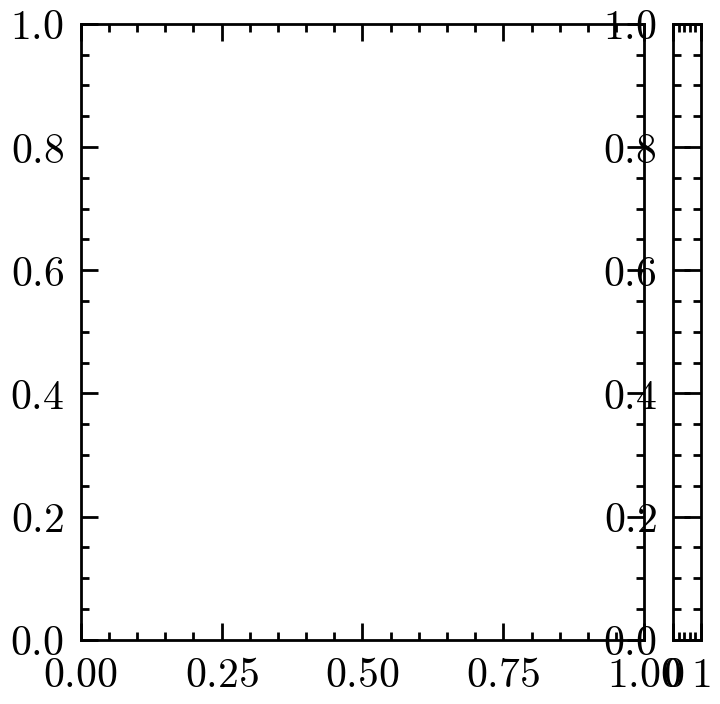

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [17]:
fig = plt.figure()
gs = gridspec.GridSpec(100, 110)
ax = fig.add_subplot(gs[:, :100])
cax = fig.add_subplot(gs[:, 105:])

bomb_spread = 0.1 *u.Msun #  see parameters file
# colors = plt.cm.Set2(np.linspace(0,1,len(models)))
mass_file = Data+'/mass.xg'
times = get_times(mass_file)
iBC_file = glob.glob(Data+"/inner_boundary.dat")[0]

tiBC, iBC = get_innerBC_t(iBC_file)

# print(times)
# times = [times[0], times[int(len(times)/2.)], times[-1]]
for i, t in enumerate(times):
    if t.to(u.h)>=4*u.h: break 
    # print(i)
    m, r, p, c = plot_mass_radius(t, mass_file, ax=ax, i_min=iBC[i], # alpha=0.5, # s=10*(1+i),
                               # c=colors[j],
                               ls='-',
                               label=f"{t.to(u.h).value:.1f}", vmin=0, vmax=4)
    j = np.argmin(np.absolute(t_shock-t))
    j_shock = int(i_shock[j])
    ax.scatter(m[j_shock].to(u.Msun), r[j_shock], c='r',  zorder=10, marker='x', s=200)
    xmin = min(m.to(u.Msun))

plt.colorbar(p, cax=cax)
# ax.legend(frameon=True, ncol=2, columnspacing=0.5, handlelength=0.05, title="time [h]")
ax.axvspan(xmin=xmin.value, xmax=bomb_spread.value, alpha=0.5, color="#808080")
# ax.set_xlim(0, 7.0)
# ax.set_ylim(-1, 2.7e12)
# ax.set_yscale('log')
ax.set_xlabel(r"mass coordinate [$M_{\odot}$]")
ax.set_ylabel(r"radius [cm]") #(r"$\log_{10}(r/\mathrm{cm})$")


/tmp/ipykernel_1381624/3777476492.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Text(0, 0.5, '$\\log_{10}(L/\\mathrm{[erg\\ s^{-1}]})$')

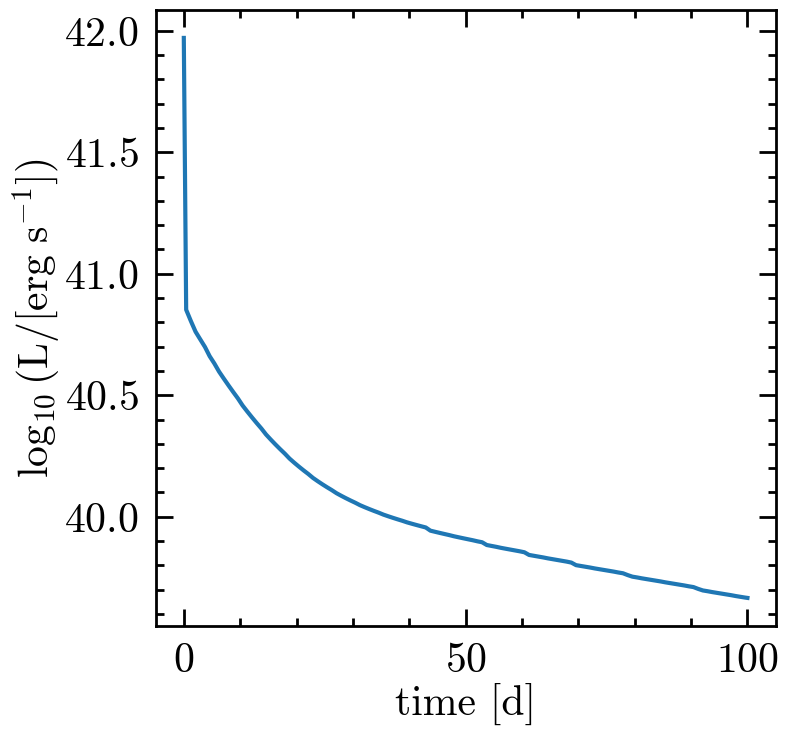

In [7]:
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])
lum_file=Data+'lum_observed.dat'
plot_LC(lum_file, ax=ax)
ax.legend()
ax.set_xlabel(r"time [d]")
ax.set_ylabel(r"$\log_{10}(L/\mathrm{[erg\ s^{-1}]})$")

/home/mrenzo/Documents/Research/codes/SNEC-1.01/scripts/plot_aux.py:455: RuntimeWarning: divide by zero encountered in log10
  ax.plot(mass.to(u.Msun), np.log10(rho.value), **kwargs)


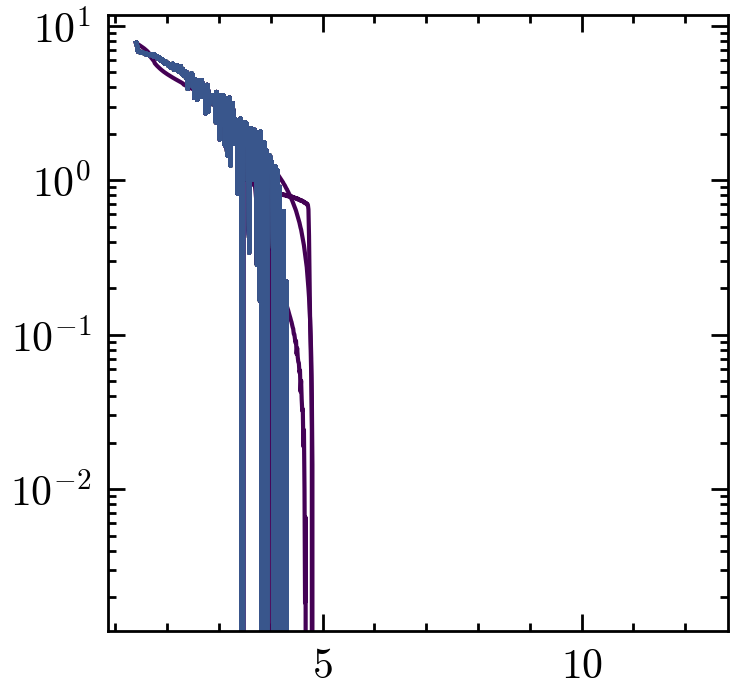

In [8]:
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])
rho_file = Data+'/rho.xg'
colors = plt.cm.viridis(np.linspace(0,1, len(times)))
# print(min(times), max(times))
for i, t in enumerate(times):
    # print(i)
    # print(t.to(u.h))
    if t.to(u.h) >= 72*u.h: break
    plot_rho_pfile(t, rho_file, ax=ax, c=colors[i]) 
ax.set_yscale('log')
#ax.set_xlim(0, 3)

In [9]:
print(len(times))

321
